In [36]:
!pip install sentence-transformers scikit-learn skl2onnx onnxruntime seaborn matplotlib

In [37]:
import re

# words that dont add meaning, strip them before embedding
FILLERS = {"um", "uh", "like", "okay", "please", "just", "so", "yeah", "yep", "hey"}

CONTRACTIONS = {
    "don't": "do not",
    "can't": "cannot",
    "i'm": "i am",
    "i've": "i have",
    "it's": "it is",
    "that's": "that is",
    "won't": "will not",
    "didn't": "did not",
    # TODO: add more if needed
}

def normalize_text(text):
    text = text.lower().strip()

    for c, expanded in CONTRACTIONS.items():
        text = text.replace(c, expanded)

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # handle repeated chars eg "staart" -> "staat" (not perfect but helps a bit)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    words = text.split()
    words = [w for w in words if w not in FILLERS]

    return " ".join(words).strip()


In [38]:
COMMANDS = {
    "decrease_volume": [
        "decrease the volume", "turn down the volume", "lower the volume",
        "volume down", "make it quieter", "reduce the sound", "turn it down",
        "can you lower the volume", "too loud turn it down", "bring the volume down",
        "less volume please", "quiet it down", "reduce volume", "sound down",
        "can you reduce the volume", "it is too loud", "lower it a bit",
        "volume is too high", "bring it down", "sound too loud lower it",
        "please decrease the volume", "make the sound lower", "turn down",
        "volume kam karo", "thoda kam karo", "bahut loud hai",
    ],

    "increase_volume": [
        "increase the volume", "turn up the volume", "raise the volume",
        "volume up", "make it louder", "louder please", "turn it up",
        "can you increase the volume", "i cannot hear bump it up", "crank up the volume",
        "more volume", "sound is too low turn it up", "raise the sound",
        "volume badao", "thoda aur loud karo", "sunai nahi de raha",
        "sound up please", "increase sound", "make it louder please",
        "can you raise the volume", "too low turn it up", "boost the volume",
        "pump up the volume", "sound zyada karo", "aur loud karo",
    ],

    "play_music": [
        "play the music", "start the music", "play music", "resume the music",
        "start playing", "play something", "turn on the music", "play a song",
        "start the song", "resume playback", "hit play", "play it",
        "music chalao", "gaana chalao", "start music", "begin playback",
        "play some music", "turn music on", "start playing music",
        "can you play music", "music start karo", "gaana shuru karo",
        "play audio", "resume music", "continue playing",
    ],

    "pause_music": [
        "pause the music", "stop the music", "pause the song", "pause it",
        "stop playing", "hold the music", "can you pause", "put the music on hold",
        "pause playback", "stop the song for now", "freeze the music", "pause please",
        "music roko", "gaana band karo", "hold on pause it", "stop music",
        "can you stop the music", "pause for a moment", "music rok do",
        "stop the audio", "hold music", "pause this song",
        "stop playing please", "pause music please", "music pause karo",
    ],

    "pick_up_call": [
        "pick up the call", "answer the call", "accept the call", "answer the phone",
        "pick up", "take the call", "receive the call", "answer it",
        "get the call", "yes answer", "pick up the phone", "accept incoming call",
        "call uthao", "phone uthao", "haan uthao", "attend the call",
        "receive incoming call", "answer please", "pick it up", "take the phone",
        "yes pick up", "answer the incoming call", "attend this call",
        "pickup the call", "get the phone",
    ],

    "decline_call": [
        "decline the call", "reject the call", "ignore the call", "do not answer",
        "dismiss the call", "hang up", "reject it", "send to voicemail",
        "decline incoming call", "no do not pick up", "cancel the call", "refuse the call",
        "call mat uthao", "nahi uthana", "cut the call", "disconnect the call",
        "do not receive the call", "reject please", "ignore it", "dismiss it",
        "send call to voicemail", "nahi chahiye call", "call cut karo",
        "decline this call", "do not answer the phone",
    ],

    "play_next_song": [
        "play the next song", "skip to next", "next song", "next track",
        "skip this song", "play the next track", "go to next song",
        "forward to next", "skip ahead", "change the song", "next one please", "skip it",
        "agla gaana chalao", "next gaana", "skip karo", "agle gaane pe jao",
        "go next", "next please", "move to next song", "forward song",
        "play next", "skip to the next one", "next track please",
        "change track", "agle gaane par",
    ],

    "play_previous_song": [
        "play the previous song", "go back to previous song", "previous track",
        "previous song", "last song", "play the last track", "go back one song",
        "rewind to previous", "back to previous", "play that last one again",
        "previous one please", "go back",
        "pichla gaana chalao", "wapas jao", "pehle wala gaana",
        "back song", "previous please", "go to last song", "play previous",
        "last track please", "rewind", "pichle gaane par jao",
        "play the song before", "go back one track", "previous gaana",
    ],

    "activate_dnd": [
        "activate do not disturb", "turn on do not disturb", "enable do not disturb",
        "do not disturb me", "activate dnd", "turn on dnd", "put on do not disturb",
        "i do not want to be disturbed", "enable dnd mode", "switch on do not disturb",
        "no disturbances please", "activate quiet mode",
        "disturb mat karo", "dnd on karo", "mujhe disturb mat karo",
        "silent mode on", "quiet mode activate", "notifications band karo",
        "do not disturb on", "enable quiet mode", "dnd lagao",
        "switch to dnd", "put on dnd mode", "no interruptions please",
    ],

    "deactivate_dnd": [
        "deactivate do not disturb", "turn off do not disturb", "disable do not disturb",
        "deactivate dnd", "turn off dnd", "disable dnd mode",
        "switch off do not disturb", "remove do not disturb", "cancel do not disturb",
        "i am available now", "turn off quiet mode", "disable quiet mode",
        "dnd hatao", "dnd band karo", "disturb karo ab", "notifications on karo",
        "remove dnd", "cancel dnd", "quiet mode off", "dnd off karo",
        "disable silent mode", "turn off dnd mode", "deactivate quiet mode",
        "i am back switch off dnd", "end do not disturb",
    ],
}


OUT_OF_SCOPE = [
    "what is the weather today", "open google maps", "how long until i reach home",
    "call mom", "what time is it", "set an alarm for 7am",
    "navigate to the nearest petrol station", "send a message to john",
    "what is the temperature outside", "open spotify",
    "how far is the nearest hospital", "remind me to buy groceries",
    "turn on the air conditioning", "what day is it today",
    "find a restaurant nearby", "how much fuel do i have",
    "read my messages", "translate hello to french",
    "what is the speed limit here", "open my calendar",
    "take a photo", "turn on bluetooth", "connect to wifi",
    "check my emails", "who is calling",
    "increase bass", "play movie", "stop playlist",
    "open youtube", "set reminder", "check traffic",
    "what song is this", "search for music", "play podcast",
    "turn on wifi", "read notifications", "open maps",
    "call office", "book a cab", "check battery",
]


EXTENSION_COMMANDS = {
    "increase_brightness": [
        "increase the brightness", "turn up the brightness", "make it brighter",
        "brightness up", "raise the brightness", "screen is too dim increase it",
        "higher brightness please", "more brightness", "brighten the screen",
        "can you increase screen brightness",
        "brightness badao", "screen roshan karo", "thoda bright karo",
        "screen dim hai increase karo", "brightness zyada karo",
        "make screen brighter", "up the brightness", "screen brightness up",
        "increase screen light", "brighter please",
    ],

    "decrease_brightness": [
        "decrease the brightness", "turn down the brightness", "make it dimmer",
        "brightness down", "lower the brightness", "reduce screen brightness",
        "screen is too bright lower it", "less brightness please",
        "dim the screen", "can you decrease the brightness",
        "brightness kam karo", "screen thanda karo", "thoda dim karo",
        "screen bahut bright hai", "brightness ghata do",
        "make screen dimmer", "down the brightness", "screen brightness down",
        "reduce screen light", "dimmer please",
    ],

    "start_vehicle": [
        "start the vehicle", "start the car", "turn on the car",
        "engine start", "start the engine", "ignition on",
        "fire up the engine", "turn the car on", "start it up", "power on the vehicle",
        "gaadi start karo", "car on karo", "engine on karo",
        "ignition start", "vehicle start karo", "car chalao",
        "start engine please", "power up the car", "vehicle on karo",
        "turn on engine",
    ],

    "stop_vehicle": [
        "stop the vehicle", "stop the car", "turn off the car",
        "engine stop", "stop the engine", "ignition off",
        "shut down the engine", "turn the car off", "switch off the vehicle",
        "power off the vehicle",
        "gaadi band karo", "car off karo", "engine band karo",
        "ignition off karo", "vehicle stop karo", "car rok do",
        "stop engine please", "power off the car", "vehicle off karo",
        "turn off engine",
    ],
}


In [40]:
import pickle
import random
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import re

# words that dont add meaning, strip them before embedding
FILLERS = {"um", "uh", "like", "okay", "please", "just", "so", "yeah", "yep", "hey"}

CONTRACTIONS = {
    "don't": "do not",
    "can't": "cannot",
    "i'm": "i am",
    "i've": "i have",
    "it's": "it is",
    "that's": "that is",
    "won't": "will not",
    "didn't": "did not"
}

def normalize_text(text):
    text = text.lower().strip()

    for c, expanded in CONTRACTIONS.items():
        text = text.replace(c, expanded)

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # handle repeated chars eg "staart" -> "staat" (not perfect but helps a bit)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    words = text.split()
    words = [w for w in words if w not in FILLERS]

    return " ".join(words).strip()


COMMANDS = {
    "decrease_volume": [
        "decrease the volume", "turn down the volume", "lower the volume",
        "volume down", "make it quieter", "reduce the sound", "turn it down",
        "can you lower the volume", "too loud turn it down", "bring the volume down",
        "less volume please", "quiet it down", "reduce volume", "sound down",
        "can you reduce the volume", "it is too loud", "lower it a bit",
        "volume is too high", "bring it down", "sound too loud lower it",
        "please decrease the volume", "make the sound lower", "turn down",
        "volume kam karo", "thoda kam karo", "bahut loud hai"
    ],

    "increase_volume": [
        "increase the volume", "turn up the volume", "raise the volume",
        "volume up", "make it louder", "louder please", "turn it up",
        "can you increase the volume", "i cannot hear bump it up", "crank up the volume",
        "more volume", "sound is too low turn it up", "raise the sound",
        "volume badao", "thoda aur loud karo", "sunai nahi de raha",
        "sound up please", "increase sound", "make it louder please",
        "can you raise the volume", "too low turn it up", "boost the volume",
        "pump up the volume", "sound zyada karo", "aur loud karo"
    ],

    "play_music": [
        "play the music", "start the music", "play music", "resume the music",
        "start playing", "play something", "turn on the music", "play a song",
        "start the song", "resume playback", "hit play", "play it",
        "music chalao", "gaana chalao", "start music", "begin playback",
        "play some music", "turn music on", "start playing music",
        "can you play music", "music start karo", "gaana shuru karo",
        "play audio", "resume music", "continue playing"
    ],

    "pause_music": [
        "pause the music", "stop the music", "pause the song", "pause it",
        "stop playing", "hold the music", "can you pause", "put the music on hold",
        "pause playback", "stop the song for now", "freeze the music", "pause please",
        "music roko", "gaana band karo", "hold on pause it", "stop music",
        "can you stop the music", "pause for a moment", "music rok do",
        "stop the audio", "hold music", "pause this song",
        "stop playing please", "pause music please", "music pause karo"
    ],

    "pick_up_call": [
        "pick up the call", "answer the call", "accept the call", "answer the phone",
        "pick up", "take the call", "receive the call", "answer it",
        "get the call", "yes answer", "pick up the phone", "accept incoming call",
        "call uthao", "phone uthao", "haan uthao", "attend the call",
        "receive incoming call", "answer please", "pick it up", "take the phone",
        "yes pick up", "answer the incoming call", "attend this call",
        "pickup the call", "get the phone"
    ],

    "decline_call": [
        "decline the call", "reject the call", "ignore the call", "do not answer",
        "dismiss the call", "hang up", "reject it", "send to voicemail",
        "decline incoming call", "no do not pick up", "cancel the call", "refuse the call",
        "call mat uthao", "nahi uthana", "cut the call", "disconnect the call",
        "do not receive the call", "reject please", "ignore it", "dismiss it",
        "send call to voicemail", "nahi chahiye call", "call cut karo",
        "decline this call", "do not answer the phone"
    ],

    "play_next_song": [
        "play the next song", "skip to next", "next song", "next track",
        "skip this song", "play the next track", "go to next song",
        "forward to next", "skip ahead", "change the song", "next one please", "skip it",
        "agla gaana chalao", "next gaana", "skip karo", "agle gaane pe jao",
        "go next", "next please", "move to next song", "forward song",
        "play next", "skip to the next one", "next track please",
        "change track", "agle gaane par"
    ],

    "play_previous_song": [
        "play the previous song", "go back to previous song", "previous track",
        "previous song", "last song", "play the last track", "go back one song",
        "rewind to previous", "back to previous", "play that last one again",
        "previous one please", "go back",
        "pichla gaana chalao", "wapas jao", "pehle wala gaana",
        "back song", "previous please", "go to last song", "play previous",
        "last track please", "rewind", "pichle gaane par jao",
        "play the song before", "go back one track", "previous gaana"
    ],

    "activate_dnd": [
        "activate do not disturb", "turn on do not disturb", "enable do not disturb",
        "do not disturb me", "activate dnd", "turn on dnd", "put on do not disturb",
        "i do not want to be disturbed", "enable dnd mode", "switch on do not disturb",
        "no disturbances please", "activate quiet mode",
        "disturb mat karo", "dnd on karo", "mujhe disturb mat karo",
        "silent mode on", "quiet mode activate", "notifications band karo",
        "do not disturb on", "enable quiet mode", "dnd lagao",
        "switch to dnd", "put on dnd mode", "no interruptions please"
    ],

    "deactivate_dnd": [
        "deactivate do not disturb", "turn off do not disturb", "disable do not disturb",
        "deactivate dnd", "turn off dnd", "disable dnd mode",
        "switch off do not disturb", "remove do not disturb", "cancel do not disturb",
        "i am available now", "turn off quiet mode", "disable quiet mode",
        "dnd hatao", "dnd band karo", "disturb karo ab", "notifications on karo",
        "remove dnd", "cancel dnd", "quiet mode off", "dnd off karo",
        "disable silent mode", "turn off dnd mode", "deactivate quiet mode",
        "i am back switch off dnd", "end do not disturb"
    ]
}


OUT_OF_SCOPE = [
    "what is the weather today", "open google maps", "how long until i reach home",
    "call mom", "what time is it", "set an alarm for 7am",
    "navigate to the nearest petrol station", "send a message to john",
    "what is the temperature outside", "open spotify",
    "how far is the nearest hospital", "remind me to buy groceries",
    "turn on the air conditioning", "what day is it today",
    "find a restaurant nearby", "how much fuel do i have",
    "read my messages", "translate hello to french",
    "what is the speed limit here", "open my calendar",
    "take a photo", "turn on bluetooth", "connect to wifi",
    "check my emails", "who is calling",
    "increase bass", "play movie", "stop playlist",
    "open youtube", "set reminder", "check traffic",
    "what song is this", "search for music", "play podcast",
    "turn on wifi", "read notifications", "open maps",
    "call office", "book a cab", "check battery"
]


EXTENSION_COMMANDS = {
    "increase_brightness": [
        "increase the brightness", "turn up the brightness", "make it brighter",
        "brightness up", "raise the brightness", "screen is too dim increase it",
        "higher brightness please", "more brightness", "brighten the screen",
        "can you increase screen brightness",
        "brightness badao", "screen roshan karo", "thoda bright karo",
        "screen dim hai increase karo", "brightness zyada karo",
        "make screen brighter", "up the brightness", "screen brightness up",
        "increase screen light", "brighter please"
    ],

    "decrease_brightness": [
        "decrease the brightness", "turn down the brightness", "make it dimmer",
        "brightness down", "lower the brightness", "reduce screen brightness",
        "screen is too bright lower it", "less brightness please",
        "dim the screen", "can you decrease the brightness",
        "brightness kam karo", "screen thanda karo", "thoda dim karo",
        "screen bahut bright hai", "brightness ghata do",
        "make screen dimmer", "down the brightness", "screen brightness down",
        "reduce screen light", "dimmer please"
    ],

    "start_vehicle": [
        "start the vehicle", "start the car", "turn on the car",
        "engine start", "start the engine", "ignition on",
        "fire up the engine", "turn the car on", "start it up", "power on the vehicle",
        "gaadi start karo", "car on karo", "engine on karo",
        "ignition start", "vehicle start karo", "car chalao",
        "start engine please", "power up the car", "vehicle on karo",
        "turn on engine"
    ],

    "stop_vehicle": [
        "stop the vehicle", "stop the car", "turn off the car",
        "engine stop", "stop the engine", "ignition off",
        "shut down the engine", "turn the car off", "switch off the vehicle",
        "power off the vehicle",
        "gaadi band karo", "car off karo", "engine band karo",
        "ignition off karo", "vehicle stop karo", "car rok do",
        "stop engine please", "power off the car", "vehicle off karo",
        "turn off engine"
    ]
}

random.seed(42)

def augment(phrase):
    words = phrase.split()
    variants = [phrase]

    if len(words) > 2:
        i = random.randint(0, len(words) - 1)
        variants.append(" ".join(words[:i] + words[i+1:]))

    for filler in ["please", "hey", "can you"]:
        variants.append(f"{filler} {phrase}")

    if len(words) >= 2:
        i = random.randint(0, len(words) - 2)
        swapped = words[:]
        swapped[i], swapped[i+1] = swapped[i+1], swapped[i]
        variants.append(" ".join(swapped))

    return variants


sentences, labels = [], []

for label, phrases in COMMANDS.items():
    for p in phrases:
        norm = normalize_text(p)
        for variant in augment(norm):
            sentences.append(variant)
            labels.append(label)

for label, phrases in EXTENSION_COMMANDS.items():
    for p in phrases:
        norm = normalize_text(p)
        for variant in augment(norm):
            sentences.append(variant)
            labels.append(label)

for p in OUT_OF_SCOPE:
    sentences.append(normalize_text(p))
    labels.append("unknown")

print(len(sentences), "examples,", len(set(labels)), "classes")

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences, show_progress_bar=True)

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"train={len(X_train)} test={len(X_test)}")

clf = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
clf.fit(X_train, y_train)

print("train acc:", round(accuracy_score(y_train, clf.predict(X_train)) * 100, 2))
print("test acc: ", round(accuracy_score(y_test, clf.predict(X_test)) * 100, 2))
print()
print(classification_report(y_test, clf.predict(X_test)))

with open("classifier.pkl", "wb") as f:
    pickle.dump(clf, f)

model.save("embedding_model")
print("done - saved classifier.pkl and embedding_model/")

1916 examples, 15 classes


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

train=1532 test=384
train acc: 99.22
test acc:  96.61

                     precision    recall  f1-score   support

       activate_dnd       0.97      1.00      0.98        28
     deactivate_dnd       1.00      0.97      0.98        29
       decline_call       1.00      0.93      0.96        29
decrease_brightness       0.96      0.96      0.96        23
    decrease_volume       0.97      0.97      0.97        30
increase_brightness       1.00      1.00      1.00        23
    increase_volume       0.97      0.97      0.97        29
        pause_music       0.93      1.00      0.97        28
       pick_up_call       0.97      1.00      0.98        29
         play_music       0.93      0.93      0.93        28
     play_next_song       1.00      1.00      1.00        27
 play_previous_song       0.96      1.00      0.98        27
      start_vehicle       0.88      0.91      0.89        23
       stop_vehicle       1.00      0.87      0.93        23
            unknown       1.0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

done - saved classifier.pkl and embedding_model/


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

EVAL 1 — CLEAN TEST
  [OK] 'make it quieter'
        expected=decrease_volume  got=decrease_volume  conf=0.96  margin=0.95

  [OK] 'volume is too high'
        expected=decrease_volume  got=decrease_volume  conf=0.93  margin=0.92

  [OK] 'turn it down'
        expected=decrease_volume  got=decrease_volume  conf=0.95  margin=0.93

  [FAIL] 'it is hurting my ears'
        expected=decrease_volume  got=unknown  conf=0.52  margin=0.41

  [OK] 'way too loud in here'
        expected=decrease_volume  got=decrease_volume  conf=0.84  margin=0.79

  [OK] 'make it louder'
        expected=increase_volume  got=increase_volume  conf=0.97  margin=0.97

  [OK] 'sound is too low turn it up'
        expected=increase_volume  got=increase_volume  conf=0.97  margin=0.96

  [OK] 'raise the sound'
        expected=increase_volume  got=increase_volume  conf=0.97  margin=0.97

  [FAIL] 'i can barely hear it'
        expected=increase_volume  got=decrease_volume  conf=0.60  margin=0.41

  [OK] 'crank it up'


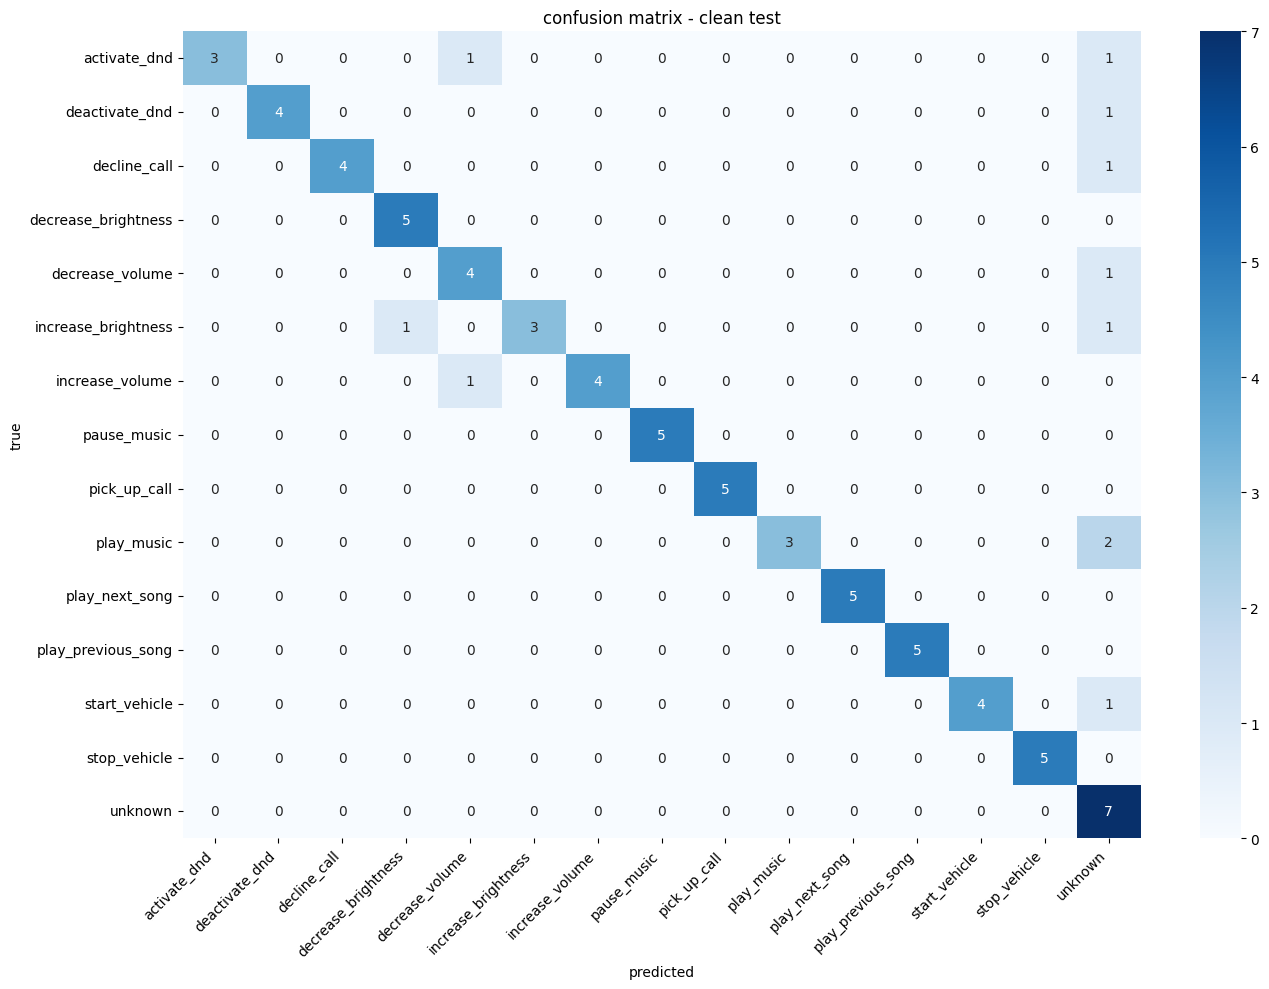

In [43]:
import pickle
import random
import json
import os
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# these thresholds came from threshold_experiment.py
CONF_THRESH  = 0.30
MARGIN_THRESH = 0.05

os.makedirs("results", exist_ok=True)

model = SentenceTransformer('embedding_model')
with open('classifier.pkl', 'rb') as f:
    clf = pickle.load(f)


def predict(text):
    text = normalize_text(text)
    emb = model.encode([text])
    probs = clf.predict_proba(emb)[0]
    top = sorted(probs, reverse=True)
    conf   = top[0]
    margin = top[0] - top[1]
    if conf < CONF_THRESH or margin < MARGIN_THRESH:
        return "unknown", conf, margin
    return clf.predict(emb)[0], conf, margin


# ------- test set -------
test_data = [
    # decrease_volume
    ("make it quieter",                "decrease_volume"),
    ("volume is too high",             "decrease_volume"),
    ("turn it down",                   "decrease_volume"),
    ("it is hurting my ears",          "decrease_volume"),
    ("way too loud in here",           "decrease_volume"),

    # increase_volume
    ("make it louder",                 "increase_volume"),
    ("sound is too low turn it up",    "increase_volume"),
    ("raise the sound",                "increase_volume"),
    ("i can barely hear it",           "increase_volume"),
    ("crank it up",                    "increase_volume"),

    # play_music
    ("start playing",                  "play_music"),
    ("play some music",                "play_music"),
    ("resume music",                   "play_music"),
    ("get some tunes going",           "play_music"),
    ("i want something to listen to",  "play_music"),

    # pause_music
    ("stop the music",                 "pause_music"),
    ("pause it",                       "pause_music"),
    ("music pause karo",               "pause_music"),
    ("cut the music",                  "pause_music"),
    ("hold on stop the song",          "pause_music"),

    # pick_up_call
    ("answer the call",                "pick_up_call"),
    ("pick up",                        "pick_up_call"),
    ("take the call",                  "pick_up_call"),
    ("yes receive it",                 "pick_up_call"),
    ("get that call",                  "pick_up_call"),

    # decline_call
    ("reject the call",                "decline_call"),
    ("ignore the call",                "decline_call"),
    ("cut the call",                   "decline_call"),
    ("not now send it away",           "decline_call"),
    ("do not answer it",               "decline_call"),

    # play_next_song
    ("next song",                      "play_next_song"),
    ("skip this song",                 "play_next_song"),
    ("next track please",              "play_next_song"),
    ("i dont like this one skip it",   "play_next_song"),
    ("move on to the next one",        "play_next_song"),

    # play_previous_song
    ("previous song",                  "play_previous_song"),
    ("go back",                        "play_previous_song"),
    ("pichla gaana chalao",            "play_previous_song"),
    ("that last song was better",      "play_previous_song"),
    ("replay the one before",          "play_previous_song"),

    # activate_dnd
    ("turn on dnd",                    "activate_dnd"),
    ("enable do not disturb",          "activate_dnd"),
    ("disturb mat karo",               "activate_dnd"),
    ("no notifications for now",       "activate_dnd"),
    ("i need some quiet",              "activate_dnd"),

    # deactivate_dnd
    ("turn off dnd",                   "deactivate_dnd"),
    ("disable do not disturb",         "deactivate_dnd"),
    ("dnd band karo",                  "deactivate_dnd"),
    ("i am available now",             "deactivate_dnd"),
    ("notifications back on",          "deactivate_dnd"),

    # increase_brightness
    ("make it brighter",               "increase_brightness"),
    ("brightness up",                  "increase_brightness"),
    ("brightness badao",               "increase_brightness"),
    ("screen is too dark",             "increase_brightness"),
    ("cant see the display",           "increase_brightness"),

    # decrease_brightness
    ("make it dimmer",                 "decrease_brightness"),
    ("brightness down",                "decrease_brightness"),
    ("thoda dim karo",                 "decrease_brightness"),
    ("screen is blinding me",          "decrease_brightness"),
    ("tone down the screen",           "decrease_brightness"),

    # start_vehicle
    ("start the car",                  "start_vehicle"),
    ("engine start",                   "start_vehicle"),
    ("gaadi start karo",               "start_vehicle"),
    ("fire it up",                     "start_vehicle"),
    ("lets get moving start it",       "start_vehicle"),

    # stop_vehicle
    ("stop the car",                   "stop_vehicle"),
    ("engine stop",                    "stop_vehicle"),
    ("gaadi band karo",                "stop_vehicle"),
    ("kill the engine",                "stop_vehicle"),
    ("shut the car off",               "stop_vehicle"),

    # OOS
    ("what is the weather today",      "unknown"),
    ("call mom",                       "unknown"),
    ("open spotify",                   "unknown"),
    ("set an alarm for 7am",           "unknown"),
    ("how far is the nearest hospital","unknown"),
    ("book a cab",                     "unknown"),
    ("what song is this",              "unknown"),
]
print("=" * 60)
print("EVAL 1 — CLEAN TEST")
print("=" * 60)

y_true, y_pred = [], []
for phrase, expected in test_data:
    pred, conf, margin = predict(phrase)
    y_true.append(expected)
    y_pred.append(pred)
    mark = "OK" if pred == expected else "FAIL"
    print(f"  [{mark}] '{phrase}'")
    print(f"        expected={expected}  got={pred}  conf={conf:.2f}  margin={margin:.2f}\n")

clean_acc = accuracy_score(y_true, y_pred)
print(f"clean accuracy: {clean_acc*100:.2f}%\n")
print(classification_report(y_true, y_pred, zero_division=0))

# false rejection = predicted unknown when it shouldnt be
valid = [(p, e) for p, e in zip(y_pred, y_true) if e != "unknown"]
false_rej = sum(1 for p, e in valid if p == "unknown")
print(f"false rejections: {false_rej}/{len(valid)}\n")


# ------- noise -------
PHONETIC = {
    "the": "da", "pause": "paws", "stop": "stap", "start": "staart",
    "answer": "answr", "reject": "rejet", "volume": "volum",
    "music": "musik", "song": "sang", "call": "cal",
    "engine": "engin", "screen": "scren", "previous": "previus",
    "disturb": "distrub", "brightness": "brightnes",
}

def add_noise(text, seed=0):
    random.seed(seed)
    ntype = random.choice(["filler_drop", "phonetic", "reorder", "merge", "repeat"])
    words = text.lower().split()

    if ntype == "filler_drop":
        filler = random.choice(["um", "uh", "like", "okay", "yaar"])
        words = [filler] + words
        if len(words) > 3:
            words.pop(random.randint(1, len(words)-1))

    elif ntype == "phonetic":
        for i, w in enumerate(words):
            if w in PHONETIC:
                words[i] = PHONETIC[w]
                break

    elif ntype == "reorder":
        if len(words) >= 3:
            i = random.randint(0, len(words)-2)
            words[i], words[i+1] = words[i+1], words[i]

    elif ntype == "merge":
        if len(words) >= 2:
            i = random.randint(0, len(words)-2)
            words = words[:i] + [words[i]+words[i+1]] + words[i+2:]

    elif ntype == "repeat":
        i = random.randint(0, len(words)-1)
        words.insert(i, words[i])

    return " ".join(words), ntype


print("=" * 60)
print("EVAL 2 — NOISE TEST")
print("=" * 60)

noise_true, noise_pred = [], []
per_type = {}

for i, (phrase, expected) in enumerate(test_data):
    noisy, ntype = add_noise(phrase, seed=42+i)
    pred, conf, _ = predict(noisy)
    noise_true.append(expected)
    noise_pred.append(pred)
    per_type.setdefault(ntype, []).append(pred == expected)
    mark = "OK" if pred == expected else "FAIL"
    print(f"  [{mark}] original: '{phrase}'")
    print(f"        noisy ({ntype}): '{noisy}'")
    print(f"        expected={expected}  got={pred}  conf={conf:.2f}\n")

noise_acc = accuracy_score(noise_true, noise_pred)
print(f"noise accuracy: {noise_acc*100:.2f}%\n")
for nt, res in per_type.items():
    print(f"  {nt}: {sum(res)}/{len(res)} = {sum(res)/len(res)*100:.0f}%")
print()
print(classification_report(noise_true, noise_pred, zero_division=0))


# ------- OOS rejection -------
oos = [
    "open google maps", "what time is it", "call my wife",
    "set an alarm for 8am", "how far is the nearest hospital",
    "send a message to john", "navigate to home", "read my notifications",
    "turn on bluetooth", "check my calendar",
    "increase bass", "play movie", "open youtube", "check traffic",
]

print("=" * 60)
print("EVAL 3 — OOS REJECTION")
print("=" * 60)

rej_count = 0
for phrase in oos:
    pred, conf, _ = predict(phrase)
    ok = pred == "unknown"
    if ok:
        rej_count += 1
    print(f"  {'REJECTED' if ok else 'WRONG ' + pred} — '{phrase}'  (conf={conf:.2f})")

print(f"\nrejection rate: {rej_count}/{len(oos)} = {rej_count/len(oos)*100:.1f}%\n")


# confusion matrix
labels_all = sorted(set(y_true + y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels_all)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_all,
            yticklabels=labels_all, cmap='Blues')
plt.title('confusion matrix - clean test')
plt.ylabel('true')
plt.xlabel('predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
print("saved results/confusion_matrix.png")

# save metrics
metrics = {
    "clean_accuracy": round(clean_acc*100, 2),
    "noise_accuracy": round(noise_acc*100, 2),
    "oos_rejection_rate": round(rej_count/len(oos)*100, 1),
    "false_rejection_rate": round(false_rej/len(valid)*100, 1),
    "conf_threshold": CONF_THRESH,
    "margin_threshold": MARGIN_THRESH,
}
with open('results/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("saved results/metrics.json")

In [ ]:
import pickle
import time
import os
import csv
import numpy as np
from sentence_transformers import SentenceTransformer
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt
from onnxruntime.quantization import quantize_dynamic, QuantType

# from utils import normalize_text  <-- This line is removed

os.makedirs("results", exist_ok=True)

print("loading models...")
model = SentenceTransformer('embedding_model')
with open('classifier.pkl', 'rb') as f:
    clf = pickle.load(f)

initial_type = [('float_input', FloatTensorType([None, 384]))]
onnx_model = convert_sklearn(clf, initial_types=initial_type, target_opset=12)

with open('classifier.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())
print("saved classifier.onnx")

quantize_dynamic('classifier.onnx', 'classifier_int8.onnx', weight_type=QuantType.QUInt8)
print("saved classifier_int8.onnx")

def get_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

pkl_size  = get_mb('classifier.pkl')
fp32_size = get_mb('classifier.onnx')
int8_size = get_mb('classifier_int8.onnx')

print(f"\nmodel sizes:")
print(f"  classifier.pkl       : {pkl_size:.3f} MB")
print(f"  classifier.onnx      : {fp32_size:.3f} MB")
print(f"  classifier_int8.onnx : {int8_size:.3f} MB")
print(f"  (int8 size is similar to fp32 — expected for SVM, quantization helps more with neural nets)\n")

sess_fp32 = rt.InferenceSession('classifier.onnx')
sess_int8 = rt.InferenceSession('classifier_int8.onnx')

inp_name = sess_fp32.get_inputs()[0].name
out_name = sess_fp32.get_outputs()[0].name

test_phrases = [
    "turn down the volume", "skip to next song",
    "answer the call", "start the engine", "pause the music",
] * 20

def run_benchmark(sess):
    times = []
    for p in test_phrases:
        emb = model.encode([normalize_text(p)]).astype(np.float32)
        t0 = time.perf_counter()
        sess.run([out_name], {inp_name: emb})
        times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.percentile(times, 95)

avg_fp32, p95_fp32 = run_benchmark(sess_fp32)
avg_int8, p95_int8 = run_benchmark(sess_int8)

print("latency (100 runs each):")
print(f"  fp32 — avg: {avg_fp32:.3f}ms  p95: {p95_fp32:.3f}ms")
print(f"  int8 — avg: {avg_int8:.3f}ms  p95: {p95_int8:.3f}ms\n")

acc_phrases = [
    ("turn down the volume",     "decrease_volume"),
    ("make it louder",           "increase_volume"),
    ("start playing music",      "play_music"),
    ("pause the song",           "pause_music"),
    ("answer the phone",         "pick_up_call"),
    ("reject the call",          "decline_call"),
    ("skip to next track",       "play_next_song"),
    ("go back to previous song", "play_previous_song"),
    ("do not disturb me",        "activate_dnd"),
    ("turn off do not disturb",  "deactivate_dnd"),
]

fp32_correct = 0
int8_correct = 0

for phrase, expected in acc_phrases:
    emb = model.encode([normalize_text(phrase)]).astype(np.float32)
    pred_fp32 = sess_fp32.run([out_name], {inp_name: emb})[0][0]
    pred_int8 = sess_int8.run([out_name], {inp_name: emb})[0][0]
    if pred_fp32 == expected:
        fp32_correct += 1
    if pred_int8 == expected:
        int8_correct += 1

fp32_acc = fp32_correct / len(acc_phrases) * 100
int8_acc  = int8_correct / len(acc_phrases) * 100

print(f"accuracy on 10 test phrases:")
print(f"  fp32: {fp32_acc:.0f}%")
print(f"  int8: {int8_acc:.0f}%\n")

print(f"size constraint  (<25MB)   : {'PASS' if int8_size < 25 else 'FAIL'}")
print(f"speed constraint (<1000ms) : {'PASS' if avg_int8 < 1000 else 'FAIL'}\n")

rows = [
    {"stage": "sklearn_pkl", "size_mb": round(pkl_size, 3),  "avg_latency_ms": "-",             "accuracy": round(fp32_acc, 1)},
    {"stage": "onnx_fp32",   "size_mb": round(fp32_size, 3), "avg_latency_ms": round(avg_fp32, 3), "accuracy": round(fp32_acc, 1)},
    {"stage": "onnx_int8",   "size_mb": round(int8_size, 3), "avg_latency_ms": round(avg_int8, 3), "accuracy": round(int8_acc, 1)},
]

with open('results/benchmark.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print("saved results/benchmark.csv")

In [ ]:
import pickle
from sentence_transformers import SentenceTransformer

CONF_THRESH   = 0.45
MARGIN_THRESH = 0.10

model = SentenceTransformer('embedding_model')
with open('classifier.pkl', 'rb') as f:
    clf = pickle.load(f)

def predict(text):
    norm = normalize_text(text)
    emb  = model.encode([norm])
    probs = clf.predict_proba(emb)[0]
    top = sorted(probs, reverse=True)
    conf, margin = top[0], top[0] - top[1]
    if conf < CONF_THRESH or margin < MARGIN_THRESH:
        return "unknown", conf
    return clf.predict(emb)[0], conf

# demo
demo = [
    ("increase the volume",       "increase_volume"),
    ("um pause music",            "pause_music"),
    ("what is the weather today", "unknown"),
    ("stop the car",              "stop_vehicle"),
    ("make it brighter",          "increase_brightness"),
    ("dont disturb me",           "activate_dnd"),
    ("skip to next track",        "play_next_song"),
    ("open navigation",           "unknown"),
    ("pick the call up",          "pick_up_call"),
    ("lower brightness",          "decrease_brightness"),
]

ok = 0
for text, expected in demo:
    got, conf = predict(text)
    correct = got == expected
    if correct: ok += 1
    mark = "ok" if correct else "FAIL"
    print(f"[{mark}] '{text}' -> {got} (conf={conf:.2f})")

print(f"\n{ok}/{len(demo)} correct")

# try a few extra ones
print("\n-- extra tests --")
extras = [
    "gaana band karo",
    "volume badao",
    "open maps",
    "start the engine",
]
for t in extras:
    label, conf = predict(t)
    print(f"  '{t}' -> {label} (conf={conf:.2f})")

In [ ]:
import pickle
import csv
import os
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score

os.makedirs("results", exist_ok=True)

model = SentenceTransformer('embedding_model')
with open('classifier.pkl', 'rb') as f:
    clf = pickle.load(f)

test_data = [
    ("turn down the volume",        "decrease_volume"),
    ("make it louder",              "increase_volume"),
    ("start playing music",         "play_music"),
    ("pause the song",              "pause_music"),
    ("answer the phone",            "pick_up_call"),
    ("reject the call",             "decline_call"),
    ("skip to next track",          "play_next_song"),
    ("go back to previous song",    "play_previous_song"),
    ("do not disturb me",           "activate_dnd"),
    ("turn off do not disturb",     "deactivate_dnd"),
    ("brighten the screen",         "increase_brightness"),
    ("dim the screen",              "decrease_brightness"),
    ("start the engine",            "start_vehicle"),
    ("turn off the car",            "stop_vehicle"),
    ("what is the weather",         "unknown"),
]

oos = [
    "open google maps", "what time is it", "call my wife",
    "set an alarm for 8am", "how far is the nearest hospital",
    "send a message to john", "navigate to home", "read my notifications",
    "turn on bluetooth", "check my calendar",
]

# sweep thresholds - picked 0.45 because its the sweet spot
THRESHOLDS = [0.30, 0.35, 0.40, 0.45, 0.50, 0.60]

def predict_t(text, thresh, margin_thresh=0.10):
    norm = normalize_text(text)
    emb  = model.encode([norm])
    probs = clf.predict_proba(emb)[0]
    top = sorted(probs, reverse=True)
    if top[0] < thresh or (top[0]-top[1]) < margin_thresh:
        return "unknown"
    return clf.predict(emb)[0]

print("thresh     clean_acc    oos_rate     false_rej")
print("-" * 48)

rows = []
y_true = [e for _, e in test_data]

for t in THRESHOLDS:
    preds = [predict_t(p, t) for p, _ in test_data]
    clean_acc = accuracy_score(y_true, preds) * 100

    rej = sum(1 for p in oos if predict_t(p, t) == "unknown")
    oos_rate = rej / len(oos) * 100

    valid = [(p, e) for p, e in zip(preds, y_true) if e != "unknown"]
    frej = sum(1 for p, e in valid if p == "unknown") / len(valid) * 100

    print(f"{t:<10} {clean_acc:<12.1f} {oos_rate:<12.1f} {frej:<12.1f}")
    rows.append({"threshold": t, "clean_acc": round(clean_acc,1),
                 "oos_rate": round(oos_rate,1), "false_rej": round(frej,1)})

with open('results/threshold_results.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader()
    w.writerows(rows)
print("saved threshold_results.csv")

In [ ]:
import pickle
from sentence_transformers import SentenceTransformer

CONF_THRESH   = 0.45
MARGIN_THRESH = 0.10

model = SentenceTransformer('embedding_model')
with open('classifier.pkl', 'rb') as f:
    clf = pickle.load(f)

def predict(text):
    norm = normalize_text(text)
    emb  = model.encode([norm])
    probs = clf.predict_proba(emb)[0]
    top = sorted(probs, reverse=True)
    conf, margin = top[0], top[0] - top[1]
    if conf < CONF_THRESH or margin < MARGIN_THRESH:
        return "unknown", conf
    return clf.predict(emb)[0], conf

# pairs that could confuse each other
tests = [
    ("increase the volume",     "increase_volume",     "increase vol vs brightness"),
    ("increase the brightness", "increase_brightness", "increase vol vs brightness"),
    ("decrease the volume",     "decrease_volume",     "decrease vol vs brightness"),
    ("decrease the brightness", "decrease_brightness", "decrease vol vs brightness"),
    ("stop the music",          "pause_music",         "stop music vs stop vehicle"),
    ("stop the vehicle",        "stop_vehicle",        "stop music vs stop vehicle"),
    ("stop the car",            "stop_vehicle",        "stop music vs stop vehicle"),
    ("play the music",          "play_music",          "play music vs next song"),
    ("play the next song",      "play_next_song",      "play music vs next song"),
    ("start the engine",        "start_vehicle",       "start vehicle vs play music"),
    ("start playing",           "play_music",          "start vehicle vs play music"),
]

ok = 0
for phrase, expected, group in tests:
    pred, conf = predict(phrase)
    correct = pred == expected
    if correct:
        ok += 1
    mark = "ok" if correct else "FAIL"
    print(f"[{mark}] {group} | '{phrase}' -> {pred} (conf={conf:.2f})")

print(f"\n{ok}/{len(tests)} correct")